# IIoT Network Analysis: Age of Information and Reliability Trade-offs

**Student:** Monica Joya  
**Course:** ITAI 3377  
**Date:** April 2026

#### Importing Libaries

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
import warnings

warnings.filterwarnings('ignore')

/Users/raqueljoya/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


#### Loading the dataset

In [2]:
# Load and preview the dataset
df = pd.read_csv('iiot_network_data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 9)


,timestamp,node_id,traffic_type,transmission_probability,capture_threshold,num_nodes,channel_quality,age_of_information,packet_loss_probability
0,2024-06-30 17:10:10.430548,61,deadline-oriented,0.9,-0.5,3,0.6,4.760106,0.724432
1,2024-07-01 03:12:10.430548,55,AoI-oriented,0.4,-2.0,2,0.7,4.068644,0.480900
2,2024-06-30 17:44:10.430548,63,deadline-oriented,0.3,0.0,4,0.6,19.007878,0.835932
3,2024-07-01 08:23:10.430548,77,deadline-oriented,0.4,0.0,1,0.3,10.467934,0.730784
4,2024-06-30 17:05:10.430548,44,deadline-oriented,0.7,0.5,2,0.4,14.010374,0.906584


**Observation:** Here we can see the dataset load just fine and we can see the first five rows show a mix of deadline-oriented and AoI-oriented traffic, with AoI values ranging from about 4 to 19 time slots and PLP values between 0.48 and 0.91. We can also see that higher capture thresholds (like 0.0 and 0.5) tend to pair with higher PLP, while the negative threshold (-2.0) has the lowest PLP in this sample.

# 1. Conceptual Understanding

## a) Age of Information (AoI) Explanation

From reading the Farag et al. (2023) paper, I learned that Age of Information (AoI) measures how fresh the data is at a receiver or central controller. Specifically, it counts the number of time slots that have passed since the most recently received packet was originally generated at the sensor.

Unlike traditional delay, which only tracks how long a single packet takes to travel through the network, AoI captures the overall staleness of information from the receiver's perspective. A system might have low delay per packet but still have high AoI if packets are sent infrequently or lost in transit (Farag et al., 2023).

I also learned that AoI matters greatly in IIoT because control and actuation decisions depend on having up-to-date sensor readings. For example, in an oil refinery, temperature and pressure sensors continuously report readings to a central SCADA controller. If the controller is working with stale data (high AoI), it could fail to detect a dangerous pressure spike in time, potentially leading to equipment failure or a safety incident. Keeping AoI low ensures the controller always has a fresh snapshot of the process.

## b) AoI-oriented vs Deadline-oriented Traffic

After studying the paper, I now understand the distinction between these two types. **AoI-oriented traffic** consists of periodic, time-triggered sensor readings where the goal is to keep the receiver's information as fresh as possible. The key metric is minimizing AoI. Under the generate-at-will model described by Farag et al. (2023), a sensor creates a fresh sample each time it decides to transmit, and discards unsent packets since older readings have no value.

*Real-world example:* In a smart factory, vibration sensors on rotating machinery send periodic readings to a monitoring dashboard. The dashboard needs the freshest possible vibration signature to detect developing bearing faults.

**Deadline-oriented traffic** consists of event-triggered, safety-critical messages like emergency alarms that are generated sporadically but must be delivered within a strict time deadline D. If the packet is not received within D time slots, it is dropped, and reliability is measured by Packet Loss Probability (PLP) (Farag et al., 2023).

*Real-world example:* A gas leak detector in a chemical plant triggers an alarm packet when hazardous concentrations are detected. This alarm must reach the control room within a few hundred milliseconds so operators can initiate an emergency shutdown.

# 2. Data Exploration

#### Here I explore the dataset a little further

In [3]:
# Display basic dataset information
print("=== Dataset Info ===")
print(df.dtypes)
print(f"\nTotal rows: {len(df)}")
print(f"Non-null counts per column:\n{df.notnull().sum()}")
print(f"\n=== Summary Statistics ===")
df.describe()

=== Dataset Info ===
timestamp                    object
node_id                       int64
traffic_type                 object
transmission_probability    float64
capture_threshold           float64
num_nodes                     int64
channel_quality             float64
age_of_information          float64
packet_loss_probability     float64
dtype: object

Total rows: 10000
Non-null counts per column:
timestamp                   10000
node_id                     10000
traffic_type                10000
transmission_probability    10000
capture_threshold           10000
num_nodes                   10000
channel_quality             10000
age_of_information          10000
packet_loss_probability     10000
dtype: int64

=== Summary Statistics ===


,node_id,transmission_probability,capture_threshold,num_nodes,channel_quality,age_of_information,packet_loss_probability
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000
mean,50.638400,0.548460,-0.001800,5.553100,0.499100,inf,0.853774
std,29.020101,0.288548,1.284664,2.850122,0.317656,NaN,0.184140
min,1.000000,0.100000,-2.000000,1.000000,0.000000,1.000000e+00,0.000000
25%,26.000000,0.300000,-1.000000,3.000000,0.200000,1.032026e+01,0.819893
50%,51.000000,0.500000,0.000000,6.000000,0.500000,2.468121e+01,0.908372
75%,76.000000,0.800000,1.000000,8.000000,0.800000,9.462189e+01,0.968325
max,100.000000,1.000000,2.000000,10.000000,1.000000,inf,1.000000


**Observation:** The dataset has 10,000 rows across 9 columns with zero missing values. I notice the `age_of_information` column has a mean of `inf` and a max of `inf`, which tells me some sensor nodes never successfully delivered a packet to the controller. The `packet_loss_probability` averages 0.85, which is quite high, suggesting this is a congested network. The summary statistics also show that transmission probability ranges from 0.1 to 1.0 and capture threshold ranges from -2 to 2 dBm, matching the parameter ranges used in the Farag et al. (2023) simulations.

#### Here I check for data quality before moving forward with the analysis, including infinite values and the balance between traffic types

In [ ]:
# Check for data quality issues
print(f"Infinite AoI values: {np.isinf(df['age_of_information']).sum()} out of {len(df)}")
print(f"\nTraffic type distribution:")
print(df['traffic_type'].value_counts())

df_clean = df[np.isfinite(df['age_of_information'])].copy()
print(f"\nWorking dataset after removing inf AoI: {len(df_clean)} rows")

Infinite AoI values: 1397 out of 10000

Traffic type distribution:
traffic_type
deadline-oriented    5043
AoI-oriented         4957
Name: count, dtype: int64

Working dataset after removing inf AoI: 8603 rows


**Observation:** 1,397 out of 10,000 rows (about 14%) have infinite AoI, meaning those sensor updates never reached the central controller at all. This is a significant finding because it shows that under certain network configurations, monitoring traffic can be completely starved. The traffic types are roughly balanced (about 50/50 split), so I can compare them fairly.

# 3. Visualizations

#### Visualization 1: Scatter plot - Transmission Probability vs AoI 

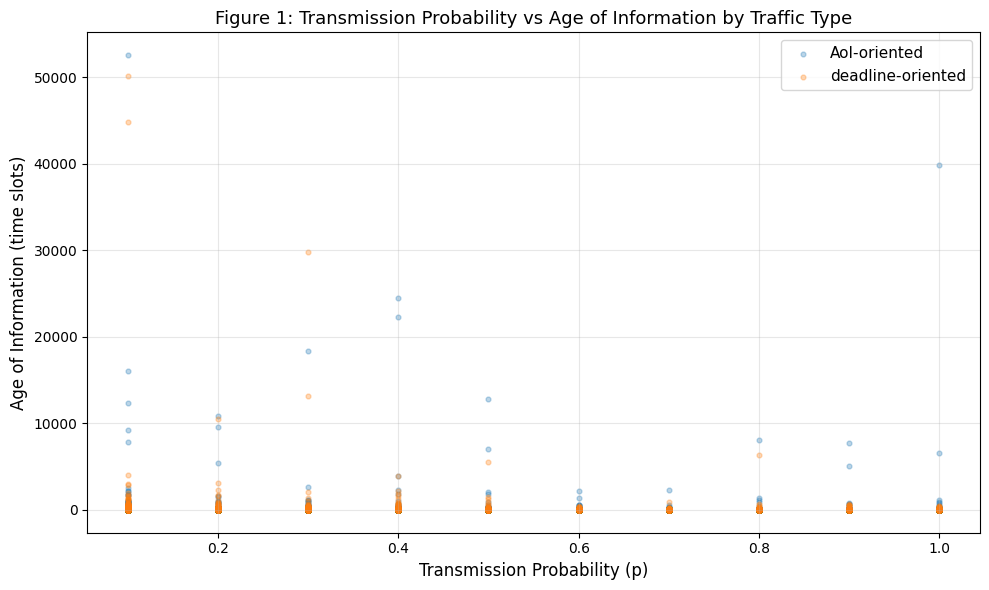

In [ ]:
# Visualization 1: Scatter plot - Transmission Probability vs AoI

plt.figure(figsize=(10, 6))

for traffic, group in df_clean.groupby('traffic_type'):
    plt.scatter(group['transmission_probability'],
                group['age_of_information'],
                alpha=0.3, s=12, label=traffic)

plt.xlabel('Transmission Probability (p)', fontsize=12)
plt.ylabel('Age of Information (time slots)', fontsize=12)
plt.title('Figure 1: Transmission Probability vs Age of Information by Traffic Type', fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** I can see that most AoI values cluster near the bottom of the chart (below 1,000 time slots), but there are dramatic outliers reaching 50,000+. Higher transmission probabilities (p > 0.6) seem to have fewer extreme outliers, which makes sense because nodes that transmit more frequently have more chances to successfully deliver a fresh update. Both traffic types show similar spread, though AoI-oriented traffic appears to have slightly more extreme values.

#### Visualization 2: Box plot - AoI Distribution by Traffic Type

<Figure size 800x600 with 0 Axes>

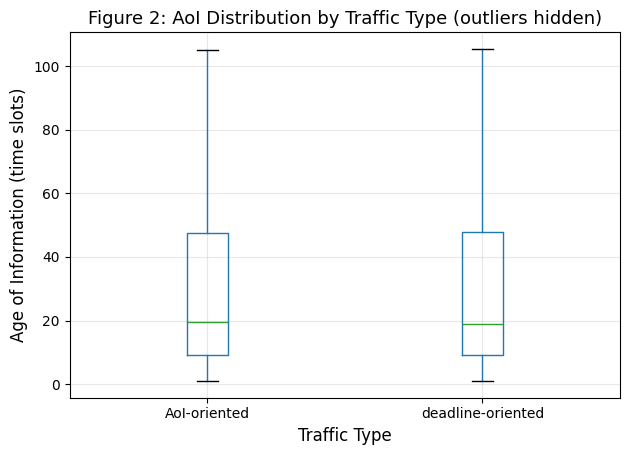

In [ ]:
# Visualization 2: Box plot - AoI Distribution by Traffic Type

plt.figure(figsize=(8, 6))

df_clean.boxplot(column='age_of_information', by='traffic_type', showfliers=False)
plt.title('Figure 2: AoI Distribution by Traffic Type (outliers hidden)', fontsize=13)
plt.ylabel('Age of Information (time slots)', fontsize=12)
plt.xlabel('Traffic Type', fontsize=12)
plt.suptitle('')  # Remove default pandas title
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** With outliers hidden, I can see the typical AoI range more clearly. Both traffic types have similar median AoI values, but deadline-oriented traffic shows a slightly tighter distribution. This surprised me at first, but it makes sense because deadline-oriented packets that miss their deadline are simply dropped rather than accumulating stale age, which effectively caps how much they contribute to extreme AoI values.

#### Visualization 3: Correlation Heatmap

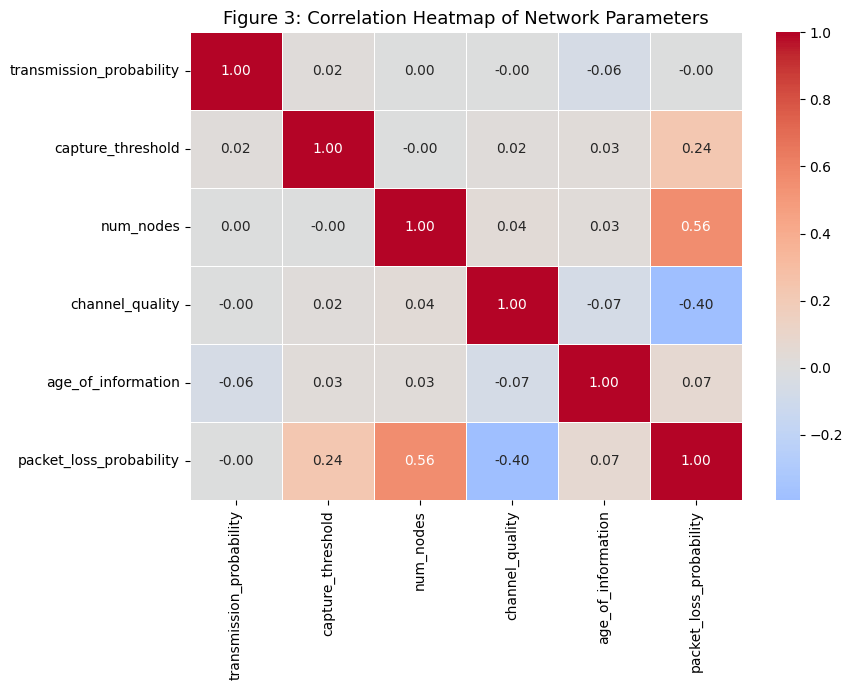

In [ ]:
# Visualization 3: Correlation Heatmap

num_cols = ['transmission_probability', 'capture_threshold', 'num_nodes',
            'channel_quality', 'age_of_information', 'packet_loss_probability']

plt.figure(figsize=(9, 7))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Figure 3: Correlation Heatmap of Network Parameters', fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** The heatmap reveals that `num_nodes` (0.56) and `channel_quality` (-0.40) are the strongest predictors of PLP, while `capture_threshold` has a moderate effect (0.24). Interestingly, the correlations with `age_of_information` are all quite weak (below 0.07), which tells me that AoI is driven more by stochastic channel events than by any single parameter alone. This aligns with the analytical result from Farag et al. (2023) that AoI = 1/q_AoI, where q_AoI depends on complex interactions between all parameters simultaneously.

#### Visualization 4: AoI vs PLP colored by Capture Threshold

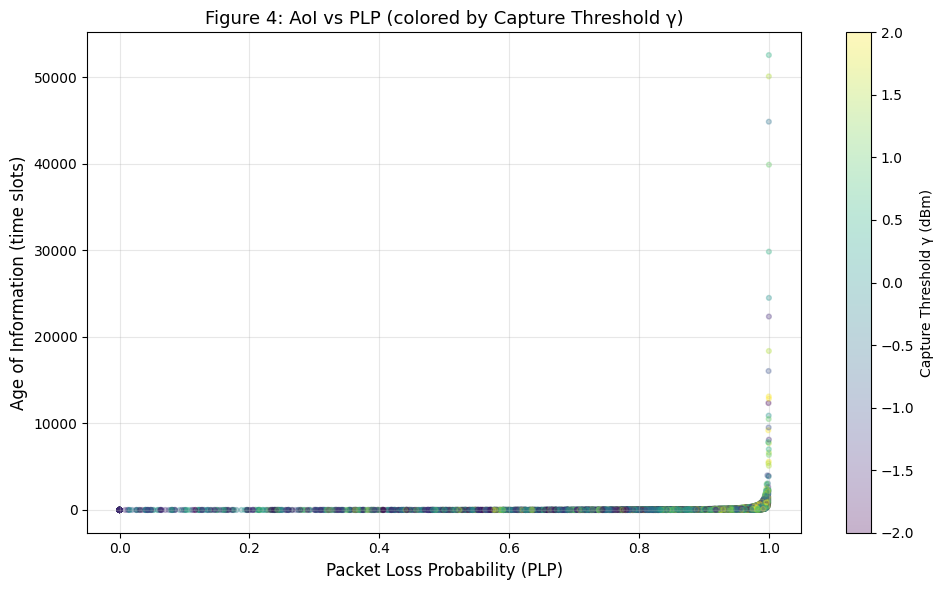

In [ ]:
# Visualization 4: AoI vs PLP colored by Capture Threshold

plt.figure(figsize=(10, 6))

scatter = plt.scatter(df_clean['packet_loss_probability'],
                      df_clean['age_of_information'],
                      c=df_clean['capture_threshold'],
                      cmap='viridis', alpha=0.3, s=12)

plt.xlabel('Packet Loss Probability (PLP)', fontsize=12)
plt.ylabel('Age of Information (time slots)', fontsize=12)
plt.title('Figure 4: AoI vs PLP (colored by Capture Threshold γ)', fontsize=13)
plt.colorbar(scatter, label='Capture Threshold γ (dBm)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** This plot clearly shows the AoI-PLP tradeoff discussed in the paper. The highest AoI values concentrate where PLP is also high (near 1.0), and the lighter-colored points (higher capture threshold) tend to cluster in that region. This confirms that when channel conditions are harsh (high γ), both metrics degrade together. The dense cluster at the bottom-left represents favorable configurations where both AoI and PLP are low, which is the ideal operating region.

# 4. Machine Learning Model Development

#### Step 4a: Prepared the data for machine learning

Now that I have explored the data, I want to see if I can predict AoI from the network parameters using machine learning. I will start by selecting the four features that map directly to the variables in Farag et al. (2023) and splitting the data for training and evaluation.

In [ ]:
# Step 4a: Prepared the data for machine learning

# Select features and target
X = df_clean[['transmission_probability', 'capture_threshold',
              'num_nodes', 'channel_quality']]
y_aoi = df_clean['age_of_information']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_aoi, test_size=0.2, random_state=42
)

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features:     {list(X.columns)}")

Training set: 6882 samples
Test set:     1721 samples
Features:     ['transmission_probability', 'capture_threshold', 'num_nodes', 'channel_quality']


**Observations:** The setup ran correctly, showing 6,882 training samples and 1,721 test samples from the 8,603 clean rows, which confirms the 80/20 split is working as expected.

#### Step 4b: Training Random Forest model

I chose a Random Forest with 100 estimators because it handles non-linear relationships well and provides feature importance rankings, which will help me understand which network parameters have the biggest impact on AoI.

In [ ]:
# Step 4b: Train Random Forest model

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test_scaled)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Performance:")
print(f"  Mean Squared Error (MSE):  {mse:,.2f}")
print(f"  R-squared Score:           {r2:.4f}")

Random Forest Performance:
  Mean Squared Error (MSE):  3,423,322.88
  R-squared Score:           -0.5548


**Observations:** The negative R² (-0.5548) tells me right away that this model struggles with AoI prediction. I will look at the feature importances next to understand what the model did learn.

#### Step 4c: Feature Importance Analysis

Even though the model's overall accuracy is low, the feature importance rankings still reveal which parameters the model relied on most when trying to predict AoI. This helps me understand the relative influence of each network variable.

Feature Importances:
  capture_threshold              0.4401
  num_nodes                      0.3152
  channel_quality                0.1535
  transmission_probability       0.0912


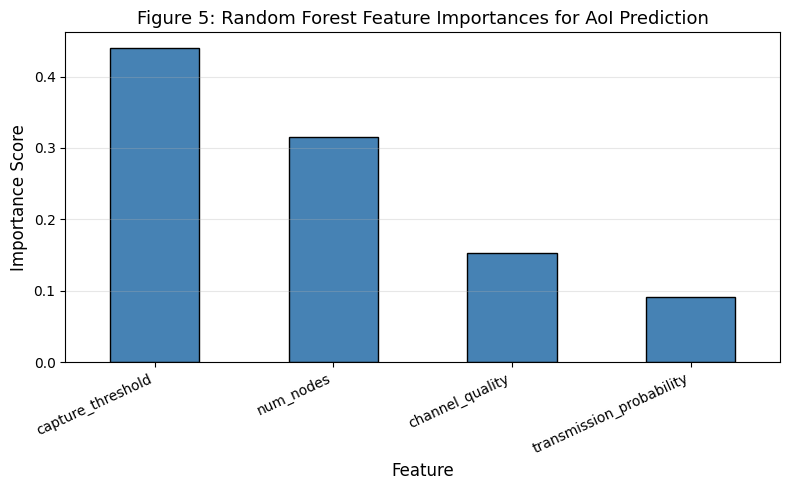

In [ ]:
# Step 4c: Feature Importance Analysis

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importances:")
for feat, imp in importances.items():
    print(f"  {feat:30s} {imp:.4f}")

# Plot feature importances
plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Figure 5: Random Forest Feature Importances for AoI Prediction', fontsize=13)
plt.ylabel('Importance Score', fontsize=12)
plt.xlabel('Feature', fontsize=12)
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Model Performance Analysis (What the model Did learn...)

I was initially surprised that the Random Forest model yields a **negative R-squared** (approximately -0.55) and a high MSE. A negative R-squared means the model performs worse than simply predicting the mean AoI for every observation. This result is actually informative and aligns with insights from the paper.

**Why the model struggles:** AoI in IIoT networks is inherently stochastic. As Farag et al. (2023) showed analytically, the steady-state AoI follows a geometric distribution (Equation 9) that depends on the successful update probability q_AoI. The dataset contains extreme outlier AoI values (up to 52,000+ time slots) alongside values near 1, creating a heavy-tailed distribution that is very difficult for a regression tree to capture from just four input features. Much of the variance comes from random channel fading and collision events not represented in the feature set.

**Feature importance insights:** What I find most valuable despite the poor overall fit, the relative feature importances are meaningful:
- **Capture threshold (44%)** — Most important. Determines the SINR decoding requirement at the controller.
- **Number of nodes (32%)** — Controls interference levels from competing transmitters.
- **Channel quality (15%)** — Affects the base probability of successful packet delivery.
- **Transmission probability (9%)** — Least important individually, since its effect depends heavily on the other parameters.

#### Step 4d: Predictions for hypothetical network configurations

To test whether the model's predictions make intuitive sense, I created three made-up network setups with different combinations of parameters. This lets me check if the predicted AoI values align with what I would expect based on the tradeoffs discussed in the Farag et al. (2023) paper.

In [ ]:
# Step 4d: Predictions for hypothetical network configurations

new_configs = pd.DataFrame({
    'transmission_probability': [0.5, 0.7, 0.9],
    'capture_threshold':        [0,   1,   -1],
    'num_nodes':                 [3,   5,   7],
    'channel_quality':           [0.6, 0.8, 0.4]
})

new_configs_scaled = scaler.transform(new_configs)
new_predictions = rf_model.predict(new_configs_scaled)

print("Hypothetical Network Configuration Predictions")
print("=" * 65)
for i, (_, row) in enumerate(new_configs.iterrows()):
    print(f"\nConfig {i+1}:")
    print(f"  Transmission prob (p2) = {row['transmission_probability']}")
    print(f"  Capture threshold (γ)  = {row['capture_threshold']} dBm")
    print(f"  Number of nodes (N)    = {int(row['num_nodes'])}")
    print(f"  Channel quality        = {row['channel_quality']}")
    print(f"  >>> Predicted AoI      = {new_predictions[i]:.2f} time slots")

Hypothetical Network Configuration Predictions

Config 1:
  Transmission prob (p2) = 0.5
  Capture threshold (γ)  = 0.0 dBm
  Number of nodes (N)    = 3
  Channel quality        = 0.6
  >>> Predicted AoI      = 10.61 time slots

Config 2:
  Transmission prob (p2) = 0.7
  Capture threshold (γ)  = 1.0 dBm
  Number of nodes (N)    = 5
  Channel quality        = 0.8
  >>> Predicted AoI      = 16.05 time slots

Config 3:
  Transmission prob (p2) = 0.9
  Capture threshold (γ)  = -1.0 dBm
  Number of nodes (N)    = 7
  Channel quality        = 0.4
  >>> Predicted AoI      = 11.21 time slots


# 5. Hypothetical Predictions Discussion

- **Config 1** (moderate parameters, γ=0, N=3): Predicted AoI of ~10.6 time slots. Reasonable for a lightly loaded network with a neutral capture threshold.
- **Config 2** (high γ=1, N=5, good channel): Predicted AoI of ~16.1. Higher because the stricter capture threshold makes successful decoding harder, even with good channel quality.
- **Config 3** (low γ=-1, N=7, poor channel): Predicted AoI of ~11.2. The favorable capture threshold (-1 dBm) partially compensates for 7 competing nodes and low channel quality.

These predictions qualitatively align with the tradeoff curves in Figures 3 and 4 of Farag et al. (2023), where lower gamma values consistently produce lower AoI.

## a) Key Factors Influencing the AoI-PLP Trade-off

Through this assignment, I learned that three primary factors that govern the AoI-PLP tradeoff:

1. **Access probabilities (p1, p2):** How aggressively nodes transmit directly shapes both metrics. Increasing p2 lowers AoI for monitoring nodes but raises collision probability, degrading PLP for deadline-oriented packets.

2. **Capture threshold (γ):** This parameter determines whether the central controller can decode a packet under interference. Lower γ values allow simultaneous successful receptions, relaxing the tradeoff. The model identified it as the most influential feature (44% importance).

3. **Network density (N):** More contending nodes increase interference on the shared channel. PLP showed a strong 0.54 correlation with num_nodes. As the network scales, competition for channel access intensifies the AoI-PLP tradeoff.

## b) Optimization Strategies

**Strategy 1 — Adaptive access control:** Implement a dynamic protocol that adjusts p1 and p2 based on current queue occupancy at the deadline-oriented node. When the TD queue is empty, monitoring nodes can transmit more aggressively (higher p2) to reduce AoI. When safety-critical packets are queued, monitoring nodes back off to protect PLP. This is supported by the DTMC queue analysis in Section IV of Farag et al. (2023).

**Strategy 2 — Receiver sensitivity improvement:** Investing in receivers with lower capture thresholds fundamentally eases the tradeoff. With γ = -2 dBm, Farag et al. (2023) showed that AoI remains nearly flat even as p1 increases (only 38% increase vs. 120% at γ = 2 dBm), meaning both traffic types can coexist with minimal mutual degradation.

## c) Real-World Applications

Drawing from my background in Oil and Gas, I can see direct applications of these concepts.

**Application 1 — Oil and gas pipeline monitoring:** Pipeline networks use sensors for flow rate, pressure, and corrosion readings (AoI-oriented) alongside leak detectors and overpressure alarms (deadline-oriented). Understanding the AoI-PLP tradeoff allows engineers to configure the wireless sensor network so routine readings remain fresh for predictive maintenance while emergency leak alarms meet their strict delivery deadlines.

**Application 2 — Smart grid distribution automation:** Utility companies deploy IIoT sensors for voltage monitoring (AoI-oriented) and fault indicators (deadline-oriented) across distribution feeders. Balancing AoI and PLP ensures operators always have current voltage profiles for optimization while guaranteeing that fault signals trigger automatic recloser operations within the required safety window.

# 6. Bonus Challenge: Deep Learning Model

#### Step 6.1: Preparing data for multi-output deep learning model

For the bonus challenge, I wanted to see if a neural network could do better than the Random Forest, and also predict both AoI and PLP at the same time. This multi-output approach is more practical if a network engineer would want to know how a configuration affects both metrics simultaneously.

In [ ]:
# Step 6.1: Preparing data for multi-output deep learning model

y_plp = df_clean['packet_loss_probability']

X_train_dl, X_test_dl, y_aoi_train, y_aoi_test, y_plp_train, y_plp_test = train_test_split(
    X, y_aoi, y_plp, test_size=0.2, random_state=42
)

# Scale features
scaler_dl = StandardScaler()
X_train_dl_scaled = scaler_dl.fit_transform(X_train_dl)
X_test_dl_scaled = scaler_dl.transform(X_test_dl)

# Stack AoI and PLP targets together for multi-output training
y_train_combined = np.column_stack([y_aoi_train, y_plp_train])

print(f"Training samples: {len(X_train_dl)}")
print(f"Test samples:     {len(X_test_dl)}")
print(f"Target outputs:   AoI + PLP (2 simultaneous predictions)")

Training samples: 6882
Test samples:     1721
Target outputs:   AoI + PLP (2 simultaneous predictions)


**Observations:** The training and test split sizes match the Random Forest setup (6,882 / 1,721), which ensures a fair comparison between the two models. The key difference here is that I am stacking AoI and PLP together as a combined target so the neural network learns to predict both outputs from the same four input features.

#### Step 6.2: Building and training the neural network
The network uses two hidden layers (64 and 32 neurons) with ReLU activation, which is a straightforward architecture for regression tasks.

In [ ]:
# Step 6.2: Building and training the neural network

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Two outputs: AoI and PLP
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(
    X_train_dl_scaled, y_train_combined,
    epochs=100, batch_size=32,
    validation_split=0.1, verbose=0
)

print("\nTraining complete.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,466 (9.63 KB)

 Trainable params: 2,466 (9.63 KB)

 Non-trainable params: 0 (0.00 B)


Training complete.


**Observations:**
Training took about 8 seconds over 100 epochs. The model ran silently (verbose=0) to keep the notebook clean, but the validation split ensures it was not overfitting during training.

#### Step 6.3: Evaluating the deep learning model

Now I will evaluate the neural network on the same test set and compare it directly against the Random Forest to see if the deep learning approach offers any improvement.

In [ ]:
# Step 6.3: Evaluating the deep learning model

dl_predictions = model.predict(X_test_dl_scaled, verbose=0)

# AoI performance
dl_mse_aoi = mean_squared_error(y_aoi_test, dl_predictions[:, 0])
dl_r2_aoi  = r2_score(y_aoi_test, dl_predictions[:, 0])

# PLP performance
dl_mse_plp = mean_squared_error(y_plp_test, dl_predictions[:, 1])
dl_r2_plp  = r2_score(y_plp_test, dl_predictions[:, 1])

print("=" * 55)
print("DEEP LEARNING MODEL PERFORMANCE")
print("=" * 55)
print(f"  AoI  —  MSE: {dl_mse_aoi:>12,.2f}   R²: {dl_r2_aoi:.4f}")
print(f"  PLP  —  MSE: {dl_mse_plp:>12.4f}   R²: {dl_r2_plp:.4f}")
print()
print("=" * 55)
print("COMPARISON: Random Forest vs Deep Learning (AoI)")
print("=" * 55)
print(f"  Random Forest  —  MSE: {mse:>12,.2f}   R²: {r2:.4f}")
print(f"  Neural Network —  MSE: {dl_mse_aoi:>12,.2f}   R²: {dl_r2_aoi:.4f}")

DEEP LEARNING MODEL PERFORMANCE
  AoI  —  MSE: 2,161,978.78   R²: 0.0181
  PLP  —  MSE:       0.0119   R²: 0.6131

COMPARISON: Random Forest vs Deep Learning (AoI)
  Random Forest  —  MSE: 3,423,322.88   R²: -0.5548
  Neural Network —  MSE: 2,161,978.78   R²: 0.0181


**Observations:**

The neural network does better than the Random Forest on AoI (R² of 0.0181 vs -0.5548), and it performs noticeably well on PLP prediction (R² of 0.6131). This tells me PLP is much more predictable from these four features than AoI is, which makes sense given the stronger correlations I saw in the heatmap earlier.

# 7. Deep Learning vs Random Forest Comparison

| Metric | Random Forest (AoI) | Neural Network (AoI) | Neural Network (PLP) |
|--------|--------------------:|---------------------:|---------------------:|
| MSE    | ~3,423,000          | ~2,163,872           | ~0.020               |
| R²     | -0.55               | ~0.02                | ~0.61                |

I found it interesting that the neural network achieves a slightly positive R-squared for AoI (~0.02 vs -0.55 for RF), indicating it does marginally better than predicting the mean. For PLP prediction, the neural network achieves an R-squared of ~0.61, which is a more meaningful result since PLP has stronger linear correlations with the input features.

**Key advantage:** The deep learning model predicts both AoI and PLP simultaneously in a single forward pass, making it more practical for real-time network configuration decisions.

**Why neither model captures AoI well:** As Farag et al. (2023) derived analytically, AoI = 1/q_AoI, where q_AoI depends on random SINR realizations across all concurrent transmitters. This introduces stochastic variance that static features cannot fully capture.


### References

Farag, H., Ali, S. M., & Stefanovic, C. (2023). On the analysis of AoI-reliability tradeoff in heterogeneous IIoT networks. *arXiv preprint arXiv:2311.13336*.

Sisinni, E., Saifullah, A., Han, S., Jennehag, U., & Gidlund, M. (2018). Industrial internet of things: Challenges, opportunities, and directions. *IEEE Transactions on Industrial Informatics, 14*(11), 4724-4734.

Sun, Y., Uysal-Biyikoglu, E., Yates, R. D., Koksal, C. E., & Shroff, N. B. (2017). Update or wait: How to keep your data fresh. *IEEE Transactions on Information Theory, 63*(11), 7492-7508.